# Atividade 6 - Desocupacao por sexo (2012 x 2026) e horas domesticas (2022)

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## 1) Abrir as duas Tabelas 5 (2012 e 2026)

In [2]:
t2012 = pd.read_csv("Tabela5-sem_emprego_2012.csv", sep=";", decimal=",", encoding="utf-8-sig")
t2012 = t2012.rename(columns={
    "Desocupados - homens (2012 T1)": "homens_2012",
    "Desocupados - mulheres (2012 T1)": "mulheres_2012",
})
t2012

,Sigla,Código,Estado,homens_2012,mulheres_2012
0,AC,12,Acre,45.3,54.7
1,AL,27,Alagoas,44.7,55.3
2,AM,13,Amazonas,47.5,52.5
3,AP,16,Amapá,48.1,51.9
4,BA,29,Bahia,43.8,56.2
5,CE,23,Ceará,51.1,48.9
6,DF,53,Distrito Federal,41.0,59.0
7,ES,32,Espírito Santo,46.4,53.6
8,GO,52,Goiás,41.0,59.0
9,MA,21,Maranhão,47.2,52.8


In [3]:
t2026 = pd.read_csv("Tabela5-sem_emprego_2026.csv", sep=";", decimal=",", encoding="utf-8-sig")
t2026 = t2026.rename(columns={
    "Desocupados - homens (2026 T1)": "homens_2026",
    "Desocupados - mulheres (2026 T1)": "mulheres_2026",
})
t2026

,Sigla,Código,Estado,homens_2026,mulheres_2026
0,AC,12,Acre,53.2,46.8
1,AL,27,Alagoas,50.7,49.3
2,AM,13,Amazonas,46.8,53.2
3,AP,16,Amapá,51.1,48.9
4,BA,29,Bahia,44.7,55.3
5,CE,23,Ceará,52.7,47.3
6,DF,53,Distrito Federal,47.9,52.1
7,ES,32,Espírito Santo,47.5,52.5
8,GO,52,Goiás,47.5,52.5
9,MA,21,Maranhão,49.1,50.9


## 2) Juntar as duas Tabelas 5

In [4]:
comp = t2012.merge(t2026, on=["Sigla", "Código", "Estado"], how="inner")
comp

,Sigla,Código,Estado,homens_2012,mulheres_2012,homens_2026,mulheres_2026
0,AC,12,Acre,45.3,54.7,53.2,46.8
1,AL,27,Alagoas,44.7,55.3,50.7,49.3
2,AM,13,Amazonas,47.5,52.5,46.8,53.2
3,AP,16,Amapá,48.1,51.9,51.1,48.9
4,BA,29,Bahia,43.8,56.2,44.7,55.3
5,CE,23,Ceará,51.1,48.9,52.7,47.3
6,DF,53,Distrito Federal,41.0,59.0,47.9,52.1
7,ES,32,Espírito Santo,46.4,53.6,47.5,52.5
8,GO,52,Goiás,41.0,59.0,47.5,52.5
9,MA,21,Maranhão,47.2,52.8,49.1,50.9


## 3) Tratar a Tabela 1.1.1 (horas semanais de afazeres domesticos, 2022)

Mesmo esquema usado na Aula 2 para tabelas do IBGE: le a planilha sem cabecalho
(`header=None`), recorta so as linhas com dados, da nome as colunas e converte
os valores para numero. No final ficamos so com os **estados** (tirando as
linhas de Brasil e das Grandes Regioes).

In [5]:
bruto = pd.read_excel("Tabela 1.1.1.xls", header=None)
bruto

,0,1,2,3,4,5,6,7
0,Tabela 1.1.1 - Número médio de horas semanais ...,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Grandes Regiões e Unidades da Federação,Número médio de horas semanais dedicadas aos c...,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,NaN,Total,Por sexo e cor ou raça,NaN,NaN,NaN,NaN,NaN
6,NaN,NaN,Total,NaN,Homem,NaN,Mulher,NaN
7,NaN,NaN,Branca,Preta ou parda,Branca,Preta ou parda,Branca,Preta ou parda
8,Brasil,16.985781,16.54593,17.333142,11.705136,11.74633,20.404106,22.037998
9,Norte,16.187037,15.925246,16.256032,11.588653,11.514646,19.29578,20.534188


In [6]:
dados = bruto.iloc[8:41].copy()

dados.columns = [
    "Estado",
    "horas_total",
    "horas_total_branca",
    "horas_total_preta_parda",
    "horas_homem_branca",
    "horas_homem_preta_parda",
    "horas_mulher_branca",
    "horas_mulher_preta_parda",
]

dados = dados.reset_index(drop=True)

for col in dados.columns[1:]:
    dados[col] = pd.to_numeric(dados[col])

dados

,Estado,horas_total,horas_total_branca,horas_total_preta_parda,horas_homem_branca,horas_homem_preta_parda,horas_mulher_branca,horas_mulher_preta_parda
0,Brasil,16.985781,16.545930,17.333142,11.705136,11.746330,20.404106,22.037998
1,Norte,16.187037,15.925246,16.256032,11.588653,11.514646,19.295780,20.534188
2,Rondônia,17.014162,16.727733,17.101523,12.111127,12.544080,20.412887,21.061410
3,Acre,13.606903,13.806929,13.541399,10.796120,9.686983,16.130352,16.710754
4,Amazonas,16.807290,15.987545,16.995493,12.233043,12.822584,18.764969,20.716986
5,Roraima,13.639257,13.651755,13.633606,10.814803,10.476601,16.135877,16.560244
6,Pará,16.474268,16.181627,16.560239,11.524306,11.026707,19.835110,21.591144
7,Amapá,13.586656,14.389180,13.415091,11.116821,10.749444,16.648579,15.908487
8,Tocantins,15.815781,15.701788,15.768728,10.733863,11.682616,19.663713,19.629399
9,Nordeste,18.499396,18.151700,18.610911,11.723907,11.848436,22.744666,23.716716


In [7]:
regioes = ["Brasil", "Norte", "Nordeste", "Sudeste", "Sul", "Centro-Oeste"]
horas = dados[~dados["Estado"].isin(regioes)].reset_index(drop=True)
horas

,Estado,horas_total,horas_total_branca,horas_total_preta_parda,horas_homem_branca,horas_homem_preta_parda,horas_mulher_branca,horas_mulher_preta_parda
0,Rondônia,17.014162,16.727733,17.101523,12.111127,12.544080,20.412887,21.061410
1,Acre,13.606903,13.806929,13.541399,10.796120,9.686983,16.130352,16.710754
2,Amazonas,16.807290,15.987545,16.995493,12.233043,12.822584,18.764969,20.716986
3,Roraima,13.639257,13.651755,13.633606,10.814803,10.476601,16.135877,16.560244
4,Pará,16.474268,16.181627,16.560239,11.524306,11.026707,19.835110,21.591144
5,Amapá,13.586656,14.389180,13.415091,11.116821,10.749444,16.648579,15.908487
6,Tocantins,15.815781,15.701788,15.768728,10.733863,11.682616,19.663713,19.629399
7,Maranhão,16.669614,16.421773,16.708894,11.665173,11.437359,19.881056,20.739589
8,Piauí,17.960366,16.948094,18.231789,12.258324,11.204814,20.494063,23.695440
9,Ceará,19.499293,18.527120,19.882469,12.186936,12.821323,23.019718,24.952274


## 4) Juntar a Tabela 1.1.1 (so estados) com a comparacao das Tabelas 5

In [8]:
comp = comp.merge(horas[["Estado", "horas_total"]], on="Estado", how="left")
comp

,Sigla,Código,Estado,homens_2012,mulheres_2012,homens_2026,mulheres_2026,horas_total
0,AC,12,Acre,45.3,54.7,53.2,46.8,13.606903
1,AL,27,Alagoas,44.7,55.3,50.7,49.3,20.217129
2,AM,13,Amazonas,47.5,52.5,46.8,53.2,16.807290
3,AP,16,Amapá,48.1,51.9,51.1,48.9,13.586656
4,BA,29,Bahia,43.8,56.2,44.7,55.3,17.849776
5,CE,23,Ceará,51.1,48.9,52.7,47.3,19.499293
6,DF,53,Distrito Federal,41.0,59.0,47.9,52.1,15.096351
7,ES,32,Espírito Santo,46.4,53.6,47.5,52.5,17.111106
8,GO,52,Goiás,41.0,59.0,47.5,52.5,15.186471
9,MA,21,Maranhão,47.2,52.8,49.1,50.9,16.669614


## 5) Grafico usando o merge: participacao feminina em 2012 T1 x 2026 T1

In [9]:
ordem = comp.sort_values("mulheres_2026")["Estado"]

longo = comp.melt(
    id_vars=["Sigla", "Código", "Estado"],
    value_vars=["mulheres_2012", "mulheres_2026"],
    var_name="Ano",
    value_name="Participacao_mulheres",
)
longo["Ano"] = longo["Ano"].map({"mulheres_2012": "2012 T1", "mulheres_2026": "2026 T1"})
longo.head()

,Sigla,Código,Estado,Ano,Participacao_mulheres
0,AC,12,Acre,2012 T1,54.7
1,AL,27,Alagoas,2012 T1,55.3
2,AM,13,Amazonas,2012 T1,52.5
3,AP,16,Amapá,2012 T1,51.9
4,BA,29,Bahia,2012 T1,56.2


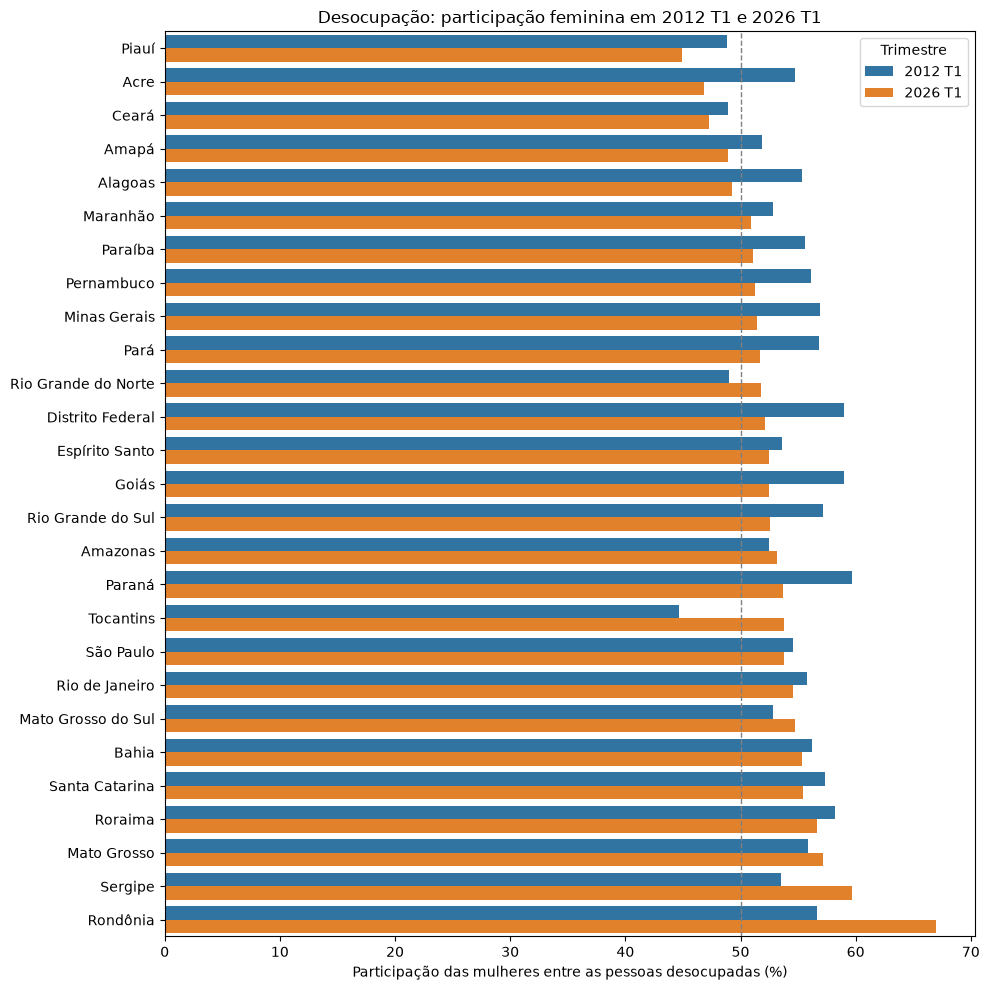

In [10]:
fig, ax = plt.subplots(figsize=(10, 10))
sns.barplot(
    data=longo,
    y="Estado",
    x="Participacao_mulheres",
    hue="Ano",
    order=ordem,
    ax=ax,
)
ax.axvline(50, color="gray", linestyle="--", linewidth=1)
ax.set_xlabel("Participação das mulheres entre as pessoas desocupadas (%)")
ax.set_ylabel("")
ax.set_title("Desocupação: participação feminina em 2012 T1 e 2026 T1")
ax.legend(title="Trimestre")
fig.tight_layout()
plt.show()

## 6) Cruzando com a Tabela 1.1.1: horas domesticas x participacao feminina

Como bonus, usamos a coluna `horas_total` (que veio da Tabela 1.1.1) para ver se
estados onde as mulheres dedicam mais horas por semana a cuidados/afazeres
domesticos tambem sao estados com maior participacao feminina entre os
desocupados em 2026 T1.

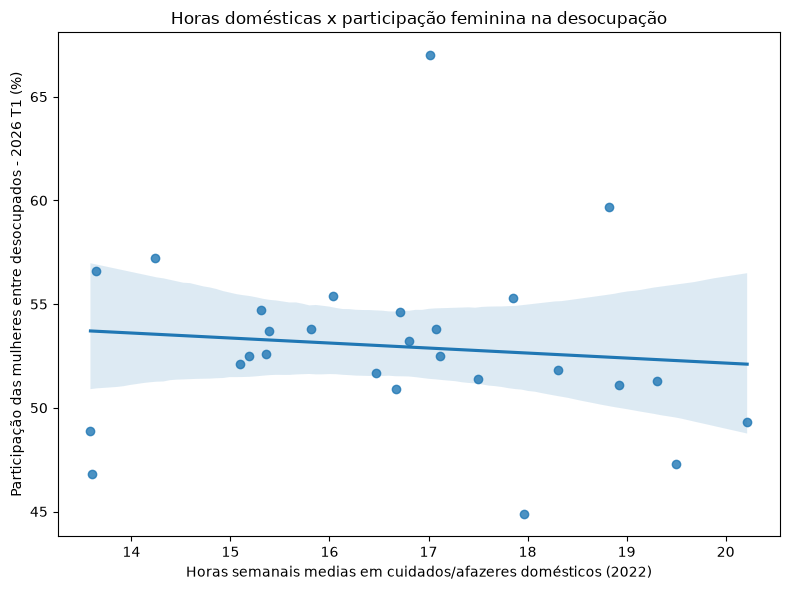

In [11]:
fig, ax = plt.subplots(figsize=(8, 6))
sns.regplot(data=comp, x="horas_total", y="mulheres_2026", ax=ax)
ax.set_xlabel("Horas semanais medias em cuidados/afazeres domésticos (2022)")
ax.set_ylabel("Participação das mulheres entre desocupados - 2026 T1 (%)")
ax.set_title("Horas domésticas x participação feminina na desocupação")
fig.tight_layout()
plt.show()